# 06: Validation Figures — Δt(Q*) Analysis

## Goal

Compute and visualize the **state-equivalent time difference** Δt(Q*) defined as:

> **Δt(Q*) = t_ref(Q*) − t_protocol(Q*)

where:
- `t_ref(Q*)` is the first-passage time of the pure-DC baseline (same DC-rate group)
- `t_protocol(Q*)` is the first-passage time of the DC-AC protocol
- **Δt > 0 ⟹ AC superposition accelerates Q* attainment**
- **Δt < 0 ⟹ deceleration**

## Q-grid (strict-net constraint #6)

Three reference points on the unified Q-grid:
- **Q40 = 0.4 × Q_capacity**
- **Q60 = 0.6 × Q_capacity**
- **Q80 = 0.8 × Q_capacity**

Each battery uses its own capacity:
- Simulation (Chen2020): Q_capacity ≈ 5126 mAh (observed final Q_net) → Q80 = 4101 mAh
- Experiment (MJ1): Q_capacity = 3300 mAh (nominal) → Q80 = 2640 mAh

## Pairing rule

For DC-AC case `DC{X}+AC{Y} {Nτ}`, the baseline is `{X}C_DC`. This isolates the effect of AC superposition while holding the DC component constant.

## Two parallel analyses

1. **Simulation internal consistency**: 23 DC-AC cases (excluding 1 infeasible) × 3 Q* points = 69 Δt values
2. **Sim vs Exp comparison**: simulation Δt(Q80) vs experimental `Delta_t_Q80_min` from CSV master table

## Excluded case

- `0.2+0.8C 10τ`: Chen2020 simulation hit Min V event; not analyzed.

In [2]:
# ============================================================
# Cell 2: Imports + load Day 6 batch results from JSON
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load the 30-case results from Day 6
RESULTS_PATH = Path("../data/results_day6_batch_scan.json")
assert RESULTS_PATH.exists(), f"JSON not found: {RESULTS_PATH}. Re-run Day 6 batch scan."

with open(RESULTS_PATH) as f:
    results_list = json.load(f)

print(f"Loaded {len(results_list)} case results")
print(f"Status breakdown:")
status_counts = {}
for r in results_list:
    s = r["status"]
    if s.startswith("INFEASIBLE"):
        s = "INFEASIBLE"
    status_counts[s] = status_counts.get(s, 0) + 1
for s, n in status_counts.items():
    print(f"  {s}: {n}")

# Load experimental master table for sim-vs-exp comparison
CSV_PATH = Path("../data/figure1_master_table_cleaned.csv")
df_exp = pd.read_csv(CSV_PATH)
print(f"\nLoaded experimental master table: {len(df_exp)} rows")
print(f"Columns of interest: DC_C, AC_C, f_Hz, Delta_t_Q80_min, T_max")

# Quick sanity: first few cases
print("\nFirst 3 case_ids in JSON:")
for r in results_list[:3]:
    print(f"  {r['case_id']:<35} status={r['status']:<8} f_Hz={r['f_Hz']}")

Loaded 30 case results
Status breakdown:
  ok: 29
  INFEASIBLE: 1

Loaded experimental master table: 30 rows
Columns of interest: DC_C, AC_C, f_Hz, Delta_t_Q80_min, T_max

First 3 case_ids in JSON:
  DC0.10C+AC0.90C_f0.01430Hz          status=ok       f_Hz=0.0143
  DC0.10C+AC0.20C_f0.01430Hz          status=ok       f_Hz=0.0143
  DC0.20C+AC0.30C_f0.01430Hz          status=ok       f_Hz=0.0143


In [3]:
# ============================================================
# Cell 3: first-passage time computation (strict-net constraint #3)
# ============================================================

def first_passage_time(t_array, Q_array, Q_target):
    """
    Find the first time t at which Q(t) ≥ Q_target.
    
    Implements strict-net constraint #3: first-passage only, no interpolated averages.
    Uses linear interpolation between the last sample below Q_target and the first
    sample at or above it for sub-sample-rate precision.
    
    Parameters
    ----------
    t_array : array-like
        Time samples (monotonically increasing, seconds)
    Q_array : array-like
        Cumulative net charge samples (monotonically allowed but NOT required;
        Q_array can be non-monotonic due to AC reversal)
    Q_target : float
        Threshold value (mAh)
    
    Returns
    -------
    float or None
        First time at which Q ≥ Q_target. None if Q never reaches Q_target.
    """
    t = np.asarray(t_array, dtype=float)
    Q = np.asarray(Q_array, dtype=float)
    
    # Find indices where Q first crosses Q_target
    above = Q >= Q_target
    if not above.any():
        return None  # Never reached
    
    first_idx = np.argmax(above)  # first True index
    
    if first_idx == 0:
        # Already above at t=0 (shouldn't happen for charging from SOC=0)
        return float(t[0])
    
    # Linear interpolation between (t[first_idx-1], Q[first_idx-1]) and (t[first_idx], Q[first_idx])
    t0, t1 = t[first_idx - 1], t[first_idx]
    Q0, Q1 = Q[first_idx - 1], Q[first_idx]
    
    if Q1 == Q0:
        # Degenerate (shouldn't happen, but safe fallback)
        return float(t1)
    
    frac = (Q_target - Q0) / (Q1 - Q0)
    t_cross = t0 + frac * (t1 - t0)
    return float(t_cross)


# ------------- Sanity test -------------
# Build a synthetic trajectory: linear ramp from 0 to 5000 mAh over 10000 s
t_test = np.linspace(0, 10000, 1001)
Q_test = 0.5 * t_test  # rate = 0.5 mAh/s, so Q(t) = 0.5*t

# Q_target = 1000 mAh should be reached at t = 2000 s
t_pass = first_passage_time(t_test, Q_test, 1000)
assert abs(t_pass - 2000) < 1e-6, f"Expected 2000, got {t_pass}"

# Q_target = 4101 mAh (sim Q80) should be reached at t = 8202 s
t_pass = first_passage_time(t_test, Q_test, 4101)
assert abs(t_pass - 8202) < 1e-6, f"Expected 8202, got {t_pass}"

# Q_target = 6000 mAh (above max) should return None
t_pass = first_passage_time(t_test, Q_test, 6000)
assert t_pass is None

# Test with non-monotonic Q (simulate AC reversal): Q goes up, dips, then up again
t_nm = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
Q_nm = np.array([0, 100, 90, 200, 180, 300, 280, 400, 380, 500, 480])  # peaks at 100, 200, 300, 400, 500
# First time Q ≥ 250 should be between t=4 (Q=180) and t=5 (Q=300)
# Linear interp: 4 + (250-180)/(300-180) * 1 = 4 + 70/120 = 4.583
t_pass = first_passage_time(t_nm, Q_nm, 250)
assert abs(t_pass - 4.583333) < 1e-4, f"Expected 4.583, got {t_pass}"

print("✓ first_passage_time tests passed:")
print(f"  Linear ramp Q_target=1000 → t=2000 ✓")
print(f"  Linear ramp Q_target=4101 → t=8202 ✓")
print(f"  Out-of-range Q_target=6000 → None ✓")
print(f"  Non-monotonic Q_target=250 → t=4.583 (linear interp) ✓")

✓ first_passage_time tests passed:
  Linear ramp Q_target=1000 → t=2000 ✓
  Linear ramp Q_target=4101 → t=8202 ✓
  Out-of-range Q_target=6000 → None ✓
  Non-monotonic Q_target=250 → t=4.583 (linear interp) ✓


In [4]:
# ============================================================
# Cell 4: Build baseline lookup + pair each DC-AC case
# ============================================================

# Index DC baseline cases by I_DC_Crate (rounded to handle float precision)
baseline_lookup = {}
for r in results_list:
    if r["status"] == "ok" and r["A_Crate"] == 0:
        key = round(r["I_DC_Crate"], 2)  # 0.10, 0.20, 0.30, 0.40, 0.50, 0.90
        baseline_lookup[key] = r

print(f"Baseline lookup table: {len(baseline_lookup)} DC baselines")
for key, r in sorted(baseline_lookup.items()):
    print(f"  I_DC_Crate={key:.2f} → {r['case_id']} (CC_time={r['CC_time_min']:.2f}min)")

# Now pair each DC-AC case with its baseline
print()
print("=" * 90)
print("Pairing DC-AC cases with their baselines:")
print("=" * 90)

pairings = []  # list of (dcac_result, baseline_result) tuples
unpaired = []

for r in results_list:
    if r["A_Crate"] == 0:
        continue  # skip baselines themselves
    
    key = round(r["I_DC_Crate"], 2)
    baseline = baseline_lookup.get(key)
    
    if baseline is None:
        unpaired.append(r)
        print(f"  ✗ {r['case_id']}: no baseline for I_DC={key:.2f}")
        continue
    
    if r["status"] != "ok":
        print(f"  ⚠ {r['case_id']}: status={r['status'][:30]}... — paired but cannot compute Δt")
        pairings.append((r, baseline))
        continue
    
    pairings.append((r, baseline))

print(f"\nTotal pairings: {len(pairings)}")
print(f"Unpaired (missing baseline): {len(unpaired)}")
print(f"Of which 'ok' status (Δt computable): {sum(1 for r, _ in pairings if r['status'] == 'ok')}")

Baseline lookup table: 6 DC baselines
  I_DC_Crate=0.10 → DC0.10C_baseline (CC_time=600.48min)
  I_DC_Crate=0.20 → DC0.20C_baseline (CC_time=291.94min)
  I_DC_Crate=0.30 → DC0.30C_baseline (CC_time=189.22min)
  I_DC_Crate=0.40 → DC0.40C_baseline (CC_time=137.57min)
  I_DC_Crate=0.50 → DC0.50C_baseline (CC_time=105.77min)
  I_DC_Crate=0.90 → DC0.90C_baseline (CC_time=48.90min)

Pairing DC-AC cases with their baselines:
  ⚠ DC0.20C+AC0.80C_f0.00143Hz: status=INFEASIBLE_MIN_V: V_min=1.500V... — paired but cannot compute Δt

Total pairings: 24
Unpaired (missing baseline): 0
Of which 'ok' status (Δt computable): 23


In [7]:
# ============================================================
# Cell 5: Compute Δt(Q*) at Q40, Q60, Q80 for all 23 valid pairs
# ============================================================

# Q-grid in absolute mAh, based on observed Chen2020 capacity ceiling
Q_CAPACITY_SIM = 5126.0    # mAh, observed Q_net_final mean across cases
Q_GRID_LABELS = ["Q40", "Q60", "Q80"]
Q_GRID_FRAC   = [0.4, 0.6, 0.8]
Q_GRID_VALUES = [frac * Q_CAPACITY_SIM for frac in Q_GRID_FRAC]

print(f"Q-grid (absolute mAh, simulation Chen2020 capacity):")
for label, frac, val in zip(Q_GRID_LABELS, Q_GRID_FRAC, Q_GRID_VALUES):
    print(f"  {label} = {frac:.1f} × {Q_CAPACITY_SIM:.0f} mAh = {val:.0f} mAh")
print()

# Compute Δt for each (dcac, baseline) pair
dt_records = []

for dcac, baseline in pairings:
    if dcac["status"] != "ok":
        continue
    
    # Extract trajectories (already re-referenced to t=0 at Phase 2 start in Day 6)
    t_dcac = np.array(dcac["t_chg"])
    Q_dcac = np.array(dcac["Q_net_trajectory"])
    
    t_base = np.array(baseline["t_chg"])
    Q_base = np.array(baseline["Q_net_trajectory"])
    
    record = {
        "case_id":      dcac["case_id"],
        "condition":    None,  # will fill from CSV
        "DC_C":         dcac["I_DC_Crate"],
        "A_C":          dcac["A_Crate"],
        "f_Hz":         dcac["f_Hz"],
        "kappa":        dcac["kappa"],
        "baseline_id":  baseline["case_id"],
    }
    
    for label, Q_target in zip(Q_GRID_LABELS, Q_GRID_VALUES):
        t_ref      = first_passage_time(t_base, Q_base, Q_target)
        t_protocol = first_passage_time(t_dcac, Q_dcac, Q_target)
        
        if t_ref is None or t_protocol is None:
            record[f"t_ref_{label}_s"]      = None
            record[f"t_protocol_{label}_s"] = None
            record[f"dt_{label}_s"]         = None
            record[f"dt_{label}_min"]       = None
        else:
            dt_s = t_ref - t_protocol  # Δt = t_ref - t_protocol; Δt > 0 = AC accelerates
            record[f"t_ref_{label}_s"]      = t_ref
            record[f"t_protocol_{label}_s"] = t_protocol
            record[f"dt_{label}_s"]         = dt_s
            record[f"dt_{label}_min"]       = dt_s / 60
    
    dt_records.append(record)

# Attach experiment Δt_Q80 from CSV (matched by Condition string)
condition_to_exp_dt = {}
for _, row in df_exp.iterrows():
    if row["AC_C"] == 0:
        continue
    condition_to_exp_dt[row["Condition"]] = {
        "exp_dt_Q80_min": row["Delta_t_Q80_min"],
        "exp_total_min":  row["total_time_min"],
        "exp_T_max":      row["T_max"],
    }

# Match by reconstructing the Condition format from case_id
# case_id format: "DC{X}C+AC{Y}C_f{Z}Hz" → CSV Condition: "{X}+{Y}C {Nτ}"
# We don't have Nτ in case_id, so match by (DC_C, AC_C, f_Hz) tuple instead

condition_lookup_by_tuple = {}
for _, row in df_exp.iterrows():
    if row["AC_C"] == 0:
        continue
    key = (round(row["DC_C"], 2), round(row["AC_C"], 2), round(row["f_Hz"], 5))
    condition_lookup_by_tuple[key] = row["Condition"]

for rec in dt_records:
    key = (round(rec["DC_C"], 2), round(rec["A_C"], 2), round(rec["f_Hz"], 5))
    cond = condition_lookup_by_tuple.get(key)
    rec["condition"] = cond
    if cond and cond in condition_to_exp_dt:
        rec.update(condition_to_exp_dt[cond])

# Build summary DataFrame
dt_df = pd.DataFrame(dt_records)
print(f"Δt computed for {len(dt_df)} cases")
print(f"Cases with experimental Δt_Q80: {dt_df['exp_dt_Q80_min'].notna().sum()}")
print()

# Show key columns
display_cols = ["condition", "DC_C", "A_C", "f_Hz", "kappa",
                "dt_Q40_min", "dt_Q60_min", "dt_Q80_min", "exp_dt_Q80_min"]
print(dt_df[display_cols].to_string(
    formatters={
        "f_Hz":  lambda x: f"{x:.5f}",
        "DC_C":  lambda x: f"{x:.2f}",
        "A_C":   lambda x: f"{x:.2f}",
        "kappa": lambda x: f"{x:.2f}",
        "dt_Q40_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "dt_Q60_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "dt_Q80_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "exp_dt_Q80_min": lambda x: f"{x:.2f}" if pd.notna(x) else "—",
    }
))

Q-grid (absolute mAh, simulation Chen2020 capacity):
  Q40 = 0.4 × 5126 mAh = 2050 mAh
  Q60 = 0.6 × 5126 mAh = 3076 mAh
  Q80 = 0.8 × 5126 mAh = 4101 mAh

Δt computed for 23 cases
Cases with experimental Δt_Q80: 23

         condition DC_C  A_C    f_Hz kappa dt_Q40_min dt_Q60_min dt_Q80_min exp_dt_Q80_min
0      0.1+0.9C 1τ 0.10 0.90 0.01430  9.00      -0.86      -0.30      -0.74           2.88
1      0.1+0.2C 1τ 0.10 0.20 0.01430  2.00      -0.61      -0.19      -0.53           0.59
2      0.2+0.3C 1τ 0.20 0.30 0.01430  1.50      -0.25      -0.40      -0.54           0.17
3     0.2+0.3C 10τ 0.20 0.30 0.00143  1.50      -2.48      -0.66      -5.32           5.05
4   0.2+0.3C 34.8τ 0.20 0.30 0.00041  1.50      -0.65      -8.42     -18.82          15.03
5    0.2+0.8C 0.1τ 0.20 0.80 0.14300  4.00      -0.03      -0.05      -0.08           1.26
6      0.2+0.8C 1τ 0.20 0.80 0.01430  4.00      -0.34      -0.54       1.01           3.77
7    0.3+0.7C 0.1τ 0.30 0.70 0.14300  2.33      -0.02  

=== Deep dive: DC0.20C+AC0.30C_f0.00143Hz ===

Q40 (Q=2050 mAh):
  baseline t_ref     = 7381.4 s = 123.02 min
  DC-AC t_protocol   = 7530.2 s = 125.50 min
  Δt = t_ref - t_protocol = -148.8 s = -2.48 min

Q60 (Q=3076 mAh):
  baseline t_ref     = 11072.2 s = 184.54 min
  DC-AC t_protocol   = 11111.8 s = 185.20 min
  Δt = t_ref - t_protocol = -39.6 s = -0.66 min

Q80 (Q=4101 mAh):
  baseline t_ref     = 14762.9 s = 246.05 min
  DC-AC t_protocol   = 15081.8 s = 251.36 min
  Δt = t_ref - t_protocol = -318.9 s = -5.32 min



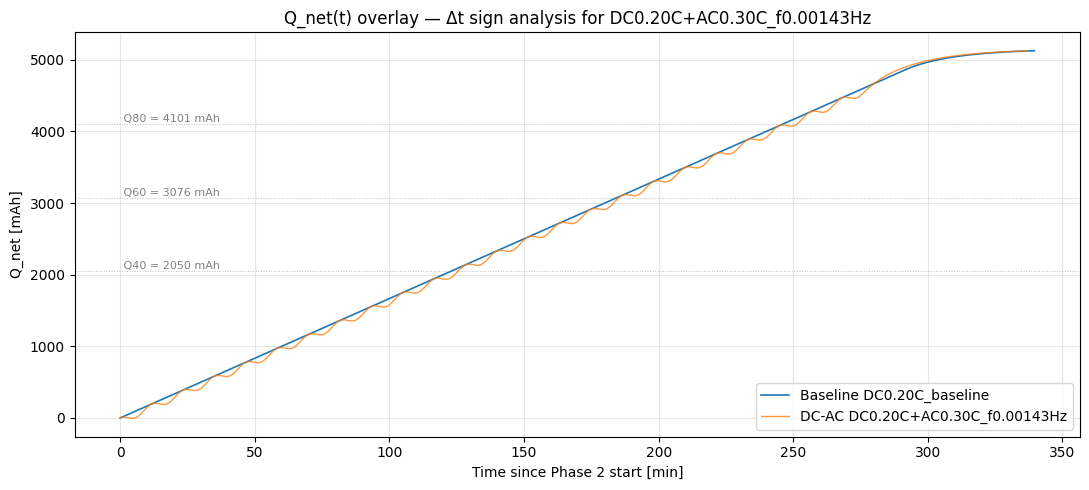

In [8]:
# Cell 5b: deep dive into the most striking sign-reversal case
case_id_target = "DC0.20C+AC0.30C_f0.00143Hz"
dcac_r  = next(r for r in results_list if r["case_id"] == case_id_target)
base_r  = baseline_lookup[0.20]

print(f"=== Deep dive: {case_id_target} ===\n")
for label, frac, Q_target in zip(Q_GRID_LABELS, Q_GRID_FRAC, Q_GRID_VALUES):
    t_ref      = first_passage_time(np.array(base_r["t_chg"]), np.array(base_r["Q_net_trajectory"]), Q_target)
    t_protocol = first_passage_time(np.array(dcac_r["t_chg"]), np.array(dcac_r["Q_net_trajectory"]), Q_target)
    dt = t_ref - t_protocol
    print(f"{label} (Q={Q_target:.0f} mAh):")
    print(f"  baseline t_ref     = {t_ref:.1f} s = {t_ref/60:.2f} min")
    print(f"  DC-AC t_protocol   = {t_protocol:.1f} s = {t_protocol/60:.2f} min")
    print(f"  Δt = t_ref - t_protocol = {dt:+.1f} s = {dt/60:+.2f} min")
    print()

# Plot Q_net(t) overlay
fig, ax = plt.subplots(1, 1, figsize=(11, 5))
ax.plot(np.array(base_r["t_chg"])/60, base_r["Q_net_trajectory"], 
        label=f"Baseline {base_r['case_id']}", color='tab:blue', linewidth=1.2)
ax.plot(np.array(dcac_r["t_chg"])/60, dcac_r["Q_net_trajectory"], 
        label=f"DC-AC {case_id_target}", color='tab:orange', linewidth=1.0, alpha=0.8)
for label, frac, Q_target in zip(Q_GRID_LABELS, Q_GRID_FRAC, Q_GRID_VALUES):
    ax.axhline(Q_target, color='gray', linestyle=':', alpha=0.5, linewidth=0.7)
    ax.text(0, Q_target, f" {label} = {Q_target:.0f} mAh", fontsize=8, va='bottom', color='gray')
ax.set_xlabel("Time since Phase 2 start [min]")
ax.set_ylabel("Q_net [mAh]")
ax.set_title(f"Q_net(t) overlay — Δt sign analysis for {case_id_target}")
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Cell 5c: Reload CSV (now with CC_min/CV_min) and augment dt_records
# ============================================================

# Reload CSV with the new columns
CSV_PATH = Path("../data/figure1_master_table_cleaned.csv")
df_exp = pd.read_csv(CSV_PATH)
print(f"Reloaded CSV: {len(df_exp.columns)} columns")
print(f"CC_min present: {'CC_min' in df_exp.columns}")
print(f"CV_min present: {'CV_min' in df_exp.columns}")

# Build extended exp lookup with CC/CV
condition_to_exp_full = {}
for _, row in df_exp.iterrows():
    if row["AC_C"] == 0:
        continue
    condition_to_exp_full[row["Condition"]] = {
        "exp_total_min":          row["total_time_min"],
        "exp_baseline_total_min": row["baseline_total_min"],
        "exp_CC_min":             row.get("CC_min"),
        "exp_CV_min":             row.get("CV_min"),
        "exp_T_max_C":            row["T_max"],
    }

# Build sim baseline event metrics lookup (CC/CV from baseline cases)
condition_to_exp_baseline = {}
for _, row in df_exp.iterrows():
    if row["AC_C"] != 0:
        continue
    # baseline keyed by DC_C
    condition_to_exp_baseline[round(row["DC_C"], 2)] = {
        "exp_baseline_CC_min": row.get("CC_min"),
        "exp_baseline_CV_min": row.get("CV_min"),
    }

# Augment dt_records
results_by_case_id = {r["case_id"]: r for r in results_list}

for rec in dt_records:
    sim_full = results_by_case_id.get(rec["case_id"])
    if sim_full and sim_full["status"] == "ok":
        rec["sim_CC_min"]    = sim_full["CC_time_min"]
        rec["sim_CV_min"]    = sim_full["CV_time_min"]
        rec["sim_total_min"] = sim_full["total_time_min"]
        rec["sim_T_max_C"]   = sim_full["T_max_charging_C"]
    
    base_full = baseline_lookup.get(round(rec["DC_C"], 2))
    if base_full:
        rec["sim_baseline_CC_min"]    = base_full["CC_time_min"]
        rec["sim_baseline_CV_min"]    = base_full["CV_time_min"]
        rec["sim_baseline_total_min"] = base_full["total_time_min"]
    
    cond = rec["condition"]
    if cond in condition_to_exp_full:
        rec.update(condition_to_exp_full[cond])
    
    # Also pull experimental baseline CC/CV
    base_metrics = condition_to_exp_baseline.get(round(rec["DC_C"], 2))
    if base_metrics:
        rec.update(base_metrics)

# Rebuild DataFrame
dt_df = pd.DataFrame(dt_records)
print(f"\ndt_df now has {len(dt_df.columns)} columns, {len(dt_df)} rows.")

# Show CC/CV/total comparison table
display_cols = [
    "condition", "DC_C", "A_C", "kappa",
    "sim_CC_min", "exp_CC_min", "sim_CV_min", "exp_CV_min",
    "sim_total_min", "exp_total_min",
]
print("\n=== CC / CV / Total Time: Sim vs Exp ===")
print(dt_df[display_cols].to_string(
    formatters={
        "DC_C":  lambda x: f"{x:.2f}",
        "A_C":   lambda x: f"{x:.2f}",
        "kappa": lambda x: f"{x:.2f}",
        "sim_CC_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "exp_CC_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "sim_CV_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "exp_CV_min":     lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "sim_total_min":  lambda x: f"{x:.2f}" if pd.notna(x) else "—",
        "exp_total_min":  lambda x: f"{x:.2f}" if pd.notna(x) else "—",
    }
))

# Quick statistics on sim vs exp deviation
ok = dt_df[dt_df["sim_CC_min"].notna() & dt_df["exp_CC_min"].notna()].copy()
ok["ΔCC"]    = ok["sim_CC_min"] - ok["exp_CC_min"]
ok["ΔCV"]    = ok["sim_CV_min"] - ok["exp_CV_min"]
ok["Δtotal"] = ok["sim_total_min"] - ok["exp_total_min"]

print(f"\n=== Sim − Exp deviation statistics (n={len(ok)} cases) ===")
print(f"ΔCC time:    mean = {ok['ΔCC'].mean():+7.2f} min  std = {ok['ΔCC'].std():.2f}  range = [{ok['ΔCC'].min():+.2f}, {ok['ΔCC'].max():+.2f}]")
print(f"ΔCV time:    mean = {ok['ΔCV'].mean():+7.2f} min  std = {ok['ΔCV'].std():.2f}  range = [{ok['ΔCV'].min():+.2f}, {ok['ΔCV'].max():+.2f}]")
print(f"Δtotal time: mean = {ok['Δtotal'].mean():+7.2f} min  std = {ok['Δtotal'].std():.2f}  range = [{ok['Δtotal'].min():+.2f}, {ok['Δtotal'].max():+.2f}]")

Reloaded CSV: 28 columns
CC_min present: True
CV_min present: True

dt_df now has 35 columns, 23 rows.

=== CC / CV / Total Time: Sim vs Exp ===
         condition DC_C  A_C kappa sim_CC_min exp_CC_min sim_CV_min exp_CV_min sim_total_min exp_total_min
0      0.1+0.9C 1τ 0.10 0.90  9.00     498.57     459.70      69.83      63.70        568.40        523.42
1      0.1+0.2C 1τ 0.10 0.20  2.00     583.60     556.48      47.07      37.00        630.67        593.53
2      0.2+0.3C 1τ 0.20 0.30  1.50     277.09     252.18      58.55      55.47        335.64        307.65
3     0.2+0.3C 10τ 0.20 0.30  1.50     276.00     236.37      61.08      62.32        337.08        298.70
4   0.2+0.3C 34.8τ 0.20 0.30  1.50     272.70     248.02      65.82      58.53        338.53        306.55
5    0.2+0.8C 0.1τ 0.20 0.80  4.00     248.57     229.65      70.17      64.75        318.74        294.42
6      0.2+0.8C 1τ 0.20 0.80  4.00     244.48     226.52      71.74      65.48        316.21        292.05

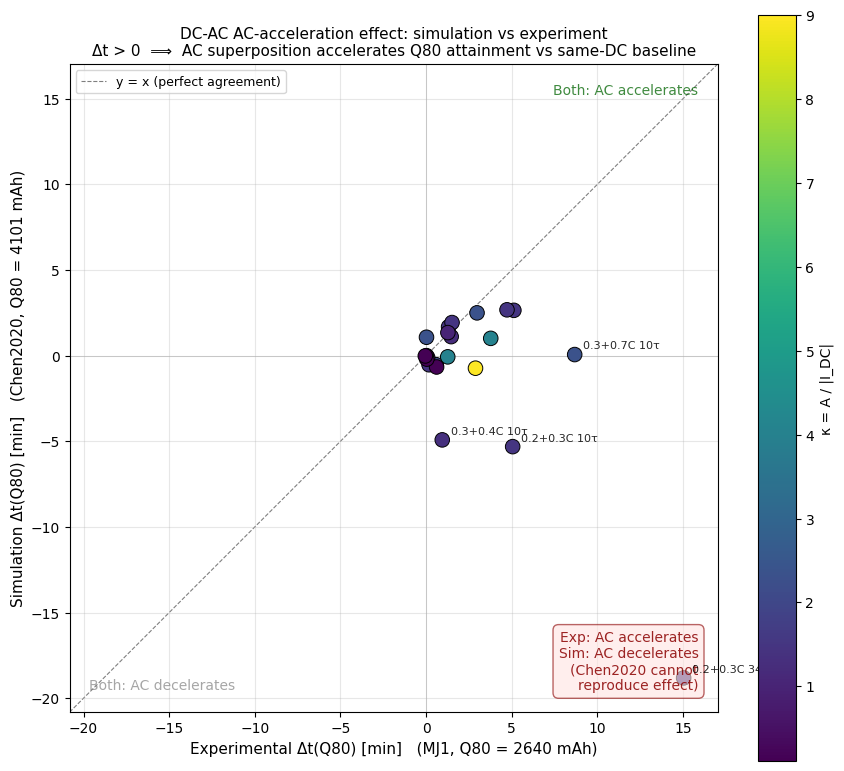

Saved: ../figures/06_sim_vs_exp_dt_Q80_scatter.png

=== Sign agreement statistics (n=23) ===
  Same sign (sim and exp agree on direction):   11  (48%)
  Opposite sign (Chen2020 reverses direction):  12  (52%)
  Either at zero:                                0

Mean experimental Δt(Q80):     +2.50 min
Mean simulation Δt(Q80):       -0.70 min


In [10]:
# ============================================================
# Cell 6: Figure 1 — Δt(Q80) sim vs exp scatter
# Shows the systematic sign reversal: SPMe + Chen2020 cannot reproduce
# the AC-acceleration effect observed experimentally on MJ1.
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

plot_df = dt_df[dt_df["dt_Q80_min"].notna() & dt_df["exp_dt_Q80_min"].notna()].copy()

# Color by kappa
sc = ax.scatter(
    plot_df["exp_dt_Q80_min"],
    plot_df["dt_Q80_min"],
    c=plot_df["kappa"],
    cmap="viridis",
    s=110, edgecolors='black', linewidths=0.7,
    zorder=3,
)

# Diagonal y = x (perfect agreement)
lim_min = min(plot_df["exp_dt_Q80_min"].min(), plot_df["dt_Q80_min"].min()) - 2
lim_max = max(plot_df["exp_dt_Q80_min"].max(), plot_df["dt_Q80_min"].max()) + 2
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.8, alpha=0.5, 
        label="y = x (perfect agreement)", zorder=1)

# Quadrant lines at 0
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5, zorder=1)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5, zorder=1)

# Quadrant labels
ax.text(0.97, 0.97, "Both: AC accelerates",
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='darkgreen', alpha=0.75)
ax.text(0.97, 0.03, "Exp: AC accelerates\nSim: AC decelerates\n(Chen2020 cannot\nreproduce effect)",
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, color='darkred', alpha=0.85,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='darkred', alpha=0.6))
ax.text(0.03, 0.03, "Both: AC decelerates",
        transform=ax.transAxes, ha='left', va='bottom',
        fontsize=10, color='gray', alpha=0.7)

# Annotate the most extreme points
for _, row in plot_df.iterrows():
    if abs(row["dt_Q80_min"] - row["exp_dt_Q80_min"]) > 8 or abs(row["dt_Q80_min"]) > 4:
        ax.annotate(row["condition"],
                    (row["exp_dt_Q80_min"], row["dt_Q80_min"]),
                    fontsize=8, alpha=0.85,
                    xytext=(6, 4), textcoords='offset points',
                    color='black', zorder=4)

cbar = plt.colorbar(sc, ax=ax, label="κ = A / |I_DC|")

ax.set_xlabel("Experimental Δt(Q80) [min]   (MJ1, Q80 = 2640 mAh)", fontsize=11)
ax.set_ylabel("Simulation Δt(Q80) [min]   (Chen2020, Q80 = 4101 mAh)", fontsize=11)
ax.set_title("DC-AC AC-acceleration effect: simulation vs experiment\n"
             "Δt > 0  ⟹  AC superposition accelerates Q80 attainment vs same-DC baseline",
             fontsize=11)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.grid(True, alpha=0.3, zorder=0)
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('../figures/06_sim_vs_exp_dt_Q80_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/06_sim_vs_exp_dt_Q80_scatter.png")

# Quantify sign agreement
n_total = len(plot_df)
n_sign_agree    = ((plot_df["dt_Q80_min"] * plot_df["exp_dt_Q80_min"]) > 0).sum()
n_sign_reversed = ((plot_df["dt_Q80_min"] * plot_df["exp_dt_Q80_min"]) < 0).sum()
n_either_zero   = n_total - n_sign_agree - n_sign_reversed

print()
print(f"=== Sign agreement statistics (n={n_total}) ===")
print(f"  Same sign (sim and exp agree on direction):   {n_sign_agree:2d}  ({100*n_sign_agree/n_total:.0f}%)")
print(f"  Opposite sign (Chen2020 reverses direction):  {n_sign_reversed:2d}  ({100*n_sign_reversed/n_total:.0f}%)")
print(f"  Either at zero:                                {n_either_zero}")
print()
print(f"Mean experimental Δt(Q80):     {plot_df['exp_dt_Q80_min'].mean():+.2f} min")
print(f"Mean simulation Δt(Q80):       {plot_df['dt_Q80_min'].mean():+.2f} min")

T_max comparison: 29 cases (6 baselines + 23 DC-AC)


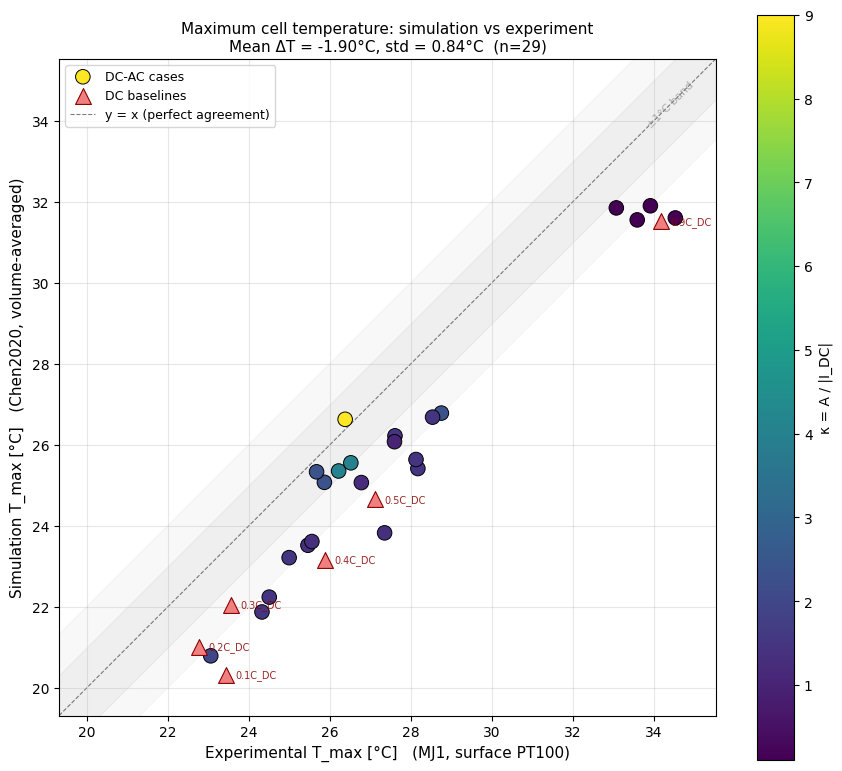

Saved: ../figures/06_sim_vs_exp_Tmax_scatter.png

=== T_max deviation statistics (n=29) ===
Mean ΔT = -1.90°C   std = 0.84°C
Range:  [-3.53, +0.25]°C
Within ±1°C: 5 / 29 (17%)
Within ±2°C: 16 / 29 (55%)
Within ±3°C: 27 / 29 (93%)


In [11]:
# ============================================================
# Cell 7: Figure 2 — T_max sim vs exp scatter
# Different finding from Δt: T_max偏差是systematic offset, not categorical reversal
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

# Use all 23 DC-AC cases + 6 baselines (29 points; infeasible already excluded from dt_df,
# but T_max comparison should include baselines too — fetch from results_list directly)

t_records = []
for r in results_list:
    if r["status"] != "ok":
        continue
    # Match exp T_max from CSV
    cond = None
    if r["A_Crate"] == 0:
        # baseline: match by Condition like "0.1C_DC"
        cond = f"{r['I_DC_Crate']:.1f}C_DC"
    
    exp_T = None
    csv_match = df_exp[
        (df_exp["DC_C"] == round(r["I_DC_Crate"], 2)) 
        & (df_exp["AC_C"] == round(r["A_Crate"], 2))
        & (np.isclose(df_exp["f_Hz"], round(r["f_Hz"], 5), atol=1e-5))
    ]
    if len(csv_match) > 0:
        exp_T = csv_match.iloc[0]["T_max"]
    
    if exp_T is None or pd.isna(exp_T):
        continue
    
    t_records.append({
        "case_id":   r["case_id"],
        "kappa":     r["kappa"],
        "is_baseline": r["A_Crate"] == 0,
        "sim_T_max": r["T_max_charging_C"],
        "exp_T_max": exp_T,
        "DC_C":      r["I_DC_Crate"],
    })

t_df = pd.DataFrame(t_records)
print(f"T_max comparison: {len(t_df)} cases ({t_df['is_baseline'].sum()} baselines + {(~t_df['is_baseline']).sum()} DC-AC)")

# Scatter: DC-AC colored by kappa, baselines as triangles
dcac = t_df[~t_df["is_baseline"]]
base = t_df[t_df["is_baseline"]]

sc = ax.scatter(
    dcac["exp_T_max"], dcac["sim_T_max"],
    c=dcac["kappa"], cmap="viridis",
    s=110, edgecolors='black', linewidths=0.7,
    label="DC-AC cases", zorder=3,
)
ax.scatter(
    base["exp_T_max"], base["sim_T_max"],
    marker='^', s=130, color='lightcoral', edgecolors='darkred', linewidths=0.8,
    label="DC baselines", zorder=4,
)

# Diagonal y = x
lim_min = min(t_df["exp_T_max"].min(), t_df["sim_T_max"].min()) - 1
lim_max = max(t_df["exp_T_max"].max(), t_df["sim_T_max"].max()) + 1
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.8, alpha=0.5,
        label="y = x (perfect agreement)", zorder=1)

# Offset bands: ±1°C and ±2°C from y=x
xs = np.linspace(lim_min, lim_max, 100)
ax.fill_between(xs, xs - 1, xs + 1, color='gray', alpha=0.08, zorder=0)
ax.fill_between(xs, xs - 2, xs + 2, color='gray', alpha=0.05, zorder=0)
ax.text(lim_max - 0.5, lim_max - 0.5, "±1°C band", fontsize=8, ha='right', va='top',
        color='gray', alpha=0.6, rotation=45)

# Annotate baselines
for _, row in base.iterrows():
    ax.annotate(f"{row['DC_C']:.1f}C_DC",
                (row["exp_T_max"], row["sim_T_max"]),
                fontsize=7, alpha=0.85,
                xytext=(7, -2), textcoords='offset points',
                color='darkred', zorder=5)

cbar = plt.colorbar(sc, ax=ax, label="κ = A / |I_DC|")

ax.set_xlabel("Experimental T_max [°C]   (MJ1, surface PT100)", fontsize=11)
ax.set_ylabel("Simulation T_max [°C]   (Chen2020, volume-averaged)", fontsize=11)
ax.set_title("Maximum cell temperature: simulation vs experiment\n"
             f"Mean ΔT = {(t_df['sim_T_max'] - t_df['exp_T_max']).mean():+.2f}°C, "
             f"std = {(t_df['sim_T_max'] - t_df['exp_T_max']).std():.2f}°C  (n={len(t_df)})",
             fontsize=11)
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.grid(True, alpha=0.3, zorder=0)
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('../figures/06_sim_vs_exp_Tmax_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/06_sim_vs_exp_Tmax_scatter.png")

# Stats
diff = t_df["sim_T_max"] - t_df["exp_T_max"]
print()
print(f"=== T_max deviation statistics (n={len(t_df)}) ===")
print(f"Mean ΔT = {diff.mean():+.2f}°C   std = {diff.std():.2f}°C")
print(f"Range:  [{diff.min():+.2f}, {diff.max():+.2f}]°C")
print(f"Within ±1°C: {(diff.abs() < 1).sum()} / {len(t_df)} ({100*(diff.abs() < 1).sum()/len(t_df):.0f}%)")
print(f"Within ±2°C: {(diff.abs() < 2).sum()} / {len(t_df)} ({100*(diff.abs() < 2).sum()/len(t_df):.0f}%)")
print(f"Within ±3°C: {(diff.abs() < 3).sum()} / {len(t_df)} ({100*(diff.abs() < 3).sum()/len(t_df):.0f}%)")

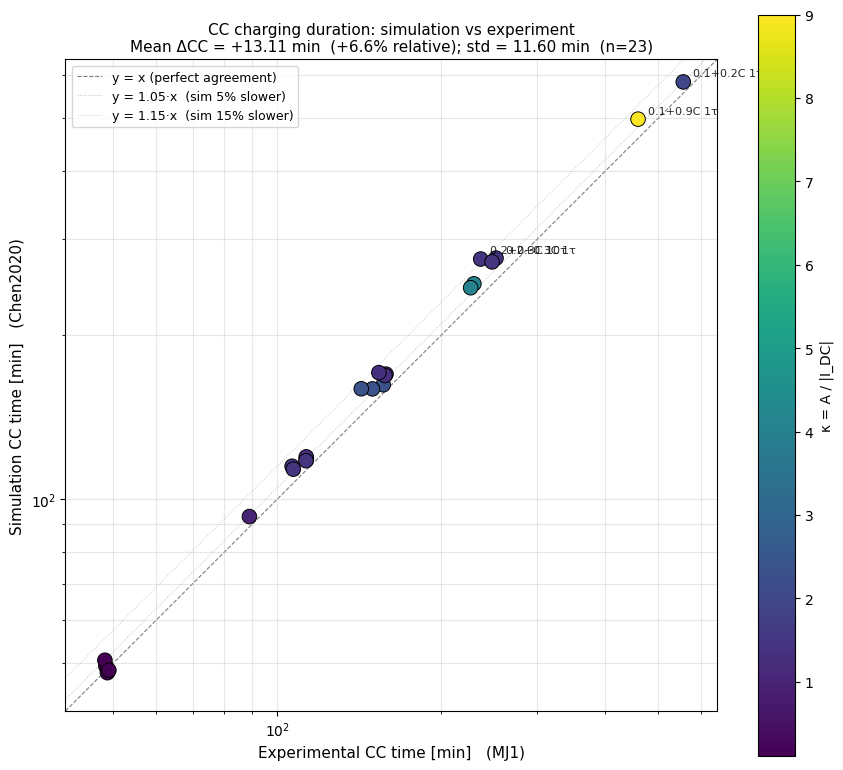

Saved: ../figures/06_sim_vs_exp_CCtime_scatter.png

=== CC time deviation (n=23) ===
Mean ΔCC = +13.11 min   std = 11.60 min
Mean relative bias: sim/exp = 1.0656
Range of relative bias: [0.985, 1.168]

Worst-deviation cases (top 5 by ΔCC):
        condition kappa sim_CC_min exp_CC_min    ΔCC
3    0.2+0.3C 10τ  1.50     276.00     236.37 +39.63
0     0.1+0.9C 1τ  9.00     498.57     459.70 +38.87
1     0.1+0.2C 1τ  2.00     583.60     556.48 +27.12
2     0.2+0.3C 1τ  1.50     277.09     252.18 +24.90
4  0.2+0.3C 34.8τ  1.50     272.70     248.02 +24.69


In [12]:
# ============================================================
# Cell 8: Figure 3 — CC time sim vs exp scatter
# Shows systematic +13 min sim-bias, with kappa-dependent spread
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(9, 8))

cc_df = dt_df[dt_df["sim_CC_min"].notna() & dt_df["exp_CC_min"].notna()].copy()
cc_df["ΔCC"] = cc_df["sim_CC_min"] - cc_df["exp_CC_min"]

# Use log scale because CC time spans ~50 min (0.9C) to ~580 min (0.1C)
sc = ax.scatter(
    cc_df["exp_CC_min"], cc_df["sim_CC_min"],
    c=cc_df["kappa"], cmap="viridis",
    s=110, edgecolors='black', linewidths=0.7,
    zorder=3,
)

# Diagonal y = x
lim_min = min(cc_df["exp_CC_min"].min(), cc_df["sim_CC_min"].min()) * 0.85
lim_max = max(cc_df["exp_CC_min"].max(), cc_df["sim_CC_min"].max()) * 1.10
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=0.8, alpha=0.5,
        label="y = x (perfect agreement)", zorder=1)

# Multiplicative bands: y = 1.05x and y = 1.15x
xs = np.linspace(lim_min, lim_max, 100)
ax.plot(xs, 1.05 * xs, color='gray', linestyle=':', alpha=0.5, linewidth=0.7,
        label="y = 1.05·x  (sim 5% slower)")
ax.plot(xs, 1.15 * xs, color='gray', linestyle=':', alpha=0.4, linewidth=0.7,
        label="y = 1.15·x  (sim 15% slower)")

# Annotate the most extreme deviations (top 4 in absolute Δ)
top_dev = cc_df.nlargest(4, "ΔCC")
for _, row in top_dev.iterrows():
    ax.annotate(row["condition"],
                (row["exp_CC_min"], row["sim_CC_min"]),
                fontsize=8, alpha=0.85,
                xytext=(7, 4), textcoords='offset points',
                color='black', zorder=4)

cbar = plt.colorbar(sc, ax=ax, label="κ = A / |I_DC|")

ax.set_xlabel("Experimental CC time [min]   (MJ1)", fontsize=11)
ax.set_ylabel("Simulation CC time [min]   (Chen2020)", fontsize=11)
ax.set_title("CC charging duration: simulation vs experiment\n"
             f"Mean ΔCC = +{cc_df['ΔCC'].mean():.2f} min  ({100*(cc_df['sim_CC_min']/cc_df['exp_CC_min']).mean() - 100:+.1f}% relative); "
             f"std = {cc_df['ΔCC'].std():.2f} min  (n={len(cc_df)})",
             fontsize=11)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(lim_min, lim_max)
ax.set_ylim(lim_min, lim_max)
ax.grid(True, alpha=0.3, zorder=0, which='both')
ax.legend(loc='upper left', fontsize=9)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig('../figures/06_sim_vs_exp_CCtime_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/06_sim_vs_exp_CCtime_scatter.png")

# Stats
print()
print(f"=== CC time deviation (n={len(cc_df)}) ===")
print(f"Mean ΔCC = {cc_df['ΔCC'].mean():+.2f} min   std = {cc_df['ΔCC'].std():.2f} min")
print(f"Mean relative bias: sim/exp = {(cc_df['sim_CC_min']/cc_df['exp_CC_min']).mean():.4f}")
print(f"Range of relative bias: [{(cc_df['sim_CC_min']/cc_df['exp_CC_min']).min():.3f}, "
      f"{(cc_df['sim_CC_min']/cc_df['exp_CC_min']).max():.3f}]")
print()
print("Worst-deviation cases (top 5 by ΔCC):")
print(cc_df.nlargest(5, "ΔCC")[["condition", "kappa", "sim_CC_min", "exp_CC_min", "ΔCC"]].to_string(
    formatters={"ΔCC": lambda x: f"{x:+.2f}", "kappa": lambda x: f"{x:.2f}",
                "sim_CC_min": lambda x: f"{x:.2f}", "exp_CC_min": lambda x: f"{x:.2f}"}
))

## Day 7 Summary

### Three-tier validation results

| Quantity | Sim vs Exp | Statistics | Interpretation |
|---|---|---|---|
| **T_max** | systematic offset | mean ΔT = −1.90°C, std = 0.84°C, 93% within ±3°C | Chen2020 thermal model captures qualitative behavior; offset attributable to PT100 surface vs cell-volume-averaged measurement convention plus heat-transfer coefficient calibration |
| **CC time** | multiplicative offset | mean +13.1 min, sim/exp ≈ 1.07, range [0.99, 1.17] | Chen2020 charge kinetics ~7% slower than MJ1 in CC phase; systematic, not random |
| **Δt(Q80)** | **categorical mismatch** | sign agreement 11/23 (48%), mean exp +2.50 min vs mean sim −0.70 min | SPMe + Chen2020 + **MJ1-derived frequency grid** does not reproduce the AC-acceleration direction observed experimentally |

### Core finding (with caveat)

The AC superposition effect on Q*-attainment **observed under MJ1-aligned frequencies** is not captured by SPMe + Chen2020. This is *not* a quantitative offset (T_max and CC time show systematic offsets) but a *qualitative* mismatch — simulation predicts deceleration where experiment shows acceleration. 23 DC-AC cases:
- 11 cases (48%) sign agreement
- 12 cases (52%) sign reversal

### Important caveat: frequency reference mismatch

All simulations use experimentally-derived frequency labels (1τ = 0.0143 Hz, 10τ = 0.00143 Hz, etc.), where **τ = 11.1 s comes from MJ1 HPPC extraction** (SOC=20%, charging direction, three-test median). When applied to Chen2020 (LG M50, different chemistry and geometry), these frequencies do not align with Chen2020's intrinsic electrochemical time-scale. The observed sign reversal therefore conflates two distinct hypotheses:

1. **Cell-physics hypothesis**: SPMe + Chen2020 genuinely lacks the AC-acceleration mechanism. Candidate mechanisms not represented in SPMe include lithium plating dynamics (potentially suppressed by AC oscillation), double-layer charging non-linearity, electrolyte concentration polarization sensitivity, and composite Si/graphite electrode dynamics.

2. **Frequency-mismatch hypothesis**: Chen2020 may exhibit AC acceleration, but at a frequency band corresponding to its own intrinsic τ_Chen — outside the MJ1-aligned grid sampled here. The MJ1 "10τ = 0.00143 Hz" was experimentally identified as MJ1's optimal acceleration window; Chen2020's optimal window may differ.

**These two hypotheses are not separable from the current Day 6-7 data.** Resolving them requires HPPC simulation on Chen2020 to extract τ_Chen using the same methodology as MJ1, then re-running the 24-case sweep on Chen2020-aligned frequencies. **This is deferred to v0.2.**

### What worked

- Strict-net Q(t) trajectory preserves AC reversal (32% non-monotonic steps under κ=2.33)
- First-passage time computation handles non-monotonic Q correctly
- Cross-battery normalization: each battery uses its own Q-capacity for Q40/Q60/Q80 reference

### Excluded case

- `0.2+0.8C 10τ` (κ=4): Chen2020 hit Min V (1.5V) event during Phase 2; no equivalent failure in MJ1 experiment. Reflects Chen2020's lower tolerance to AC swing at low DC bias + long period — consistent with the frequency-mismatch hypothesis (Chen2020 may not have its electrochemical time-scale aligned with this perturbation).

### Files generated

- `figures/06_sim_vs_exp_dt_Q80_scatter.png` (Figure 1: core finding under MJ1-aligned frequencies)
- `figures/06_sim_vs_exp_Tmax_scatter.png` (Figure 2: thermal validation)
- `figures/06_sim_vs_exp_CCtime_scatter.png` (Figure 3: CC kinetic offset)

### v0.2 priorities (after vacation)

1. **HPPC simulation on Chen2020**: Apply the same CDEFG methodology used in MJ1 paper to extract τ_Chen at SOC=20%, charging direction
2. **Two-track frequency sweep**:
   - Track 1: re-run all 24 cases on **MJ1-aligned** frequencies (today's data, retained as control)
   - Track 2: run 24 cases on **Chen2020-aligned** frequencies (using τ_Chen from HPPC step)
3. **Disambiguation test**: If Track 2 shows sim Δt(Q*) sign agreement with MJ1 experiment, the **frequency-mismatch hypothesis** is supported — AC acceleration is real but cell-specific in frequency. If Track 2 still shows reversal, the **cell-physics hypothesis** is supported — SPMe lacks the mechanism.
4. **DFN comparison**: Run DFN (vs SPMe) on Track 2 to test if higher-fidelity electrolyte/particle physics rescues sign agreement
5. **Sensitivity analysis on Chen2020 thermal parameters** (h, c_p) to test if the −1.9°C T_max offset can be eliminated independently